# Sign Language ABC: Transfer Learning with MobileNetV2 🤟🚀


**MobileNetV2** was pretrained on ImageNet (1.4 million images, 1000 classes). It already knows what edges, textures, skin, and shapes look like. We just replace the final classification layer and fine-tune.

**Two-phase training:**
1. **Feature extraction** — freeze MobileNetV2, only train the new classifier head
2. **Fine-tuning** — unfreeze the last layers of MobileNetV2 and train with a very low learning rate

---
## 1.&nbsp; Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import classification_report, confusion_matrix
from typing import Dict
from tensorflow.data import Dataset

---
## 2.&nbsp; Load Data

In [2]:
PROCESSED_DIR: str = os.path.expanduser('~/Downloads/processed')

def load_datasets(
    processed_dir: str,
    batch_size: int = 32
) -> Dict[str, Dataset]:
    splits = [s for s in os.listdir(processed_dir)
              if os.path.isdir(os.path.join(processed_dir, s))]
    datasets = {}
    for split in splits:
        ds = tf.data.Dataset.load(os.path.join(processed_dir, split))
        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        datasets[split] = ds
        print(f'{split:5s}: loaded')
    return datasets

BATCH_SIZE: int = 32
datasets = load_datasets(PROCESSED_DIR, BATCH_SIZE)

for split_name, ds in datasets.items():
    count = sum(labels.shape[0] for _, labels in ds)
    print(f'{split_name:5s}: {count} images')

test : loaded
train: loaded
val  : loaded
test : 199 images
train: 981 images
val  : 199 images


In [3]:
for images, labels in datasets['train'].take(1):
    IMG_SHAPE = tuple(images.shape[1:])
    print(f'Image shape: {IMG_SHAPE}')
    print(f'Label dtype: {labels.dtype}')

NUM_CLASSES: int = 3
class_names: list[str] = ['A', 'B', 'C']

Image shape: (256, 256, 3)
Label dtype: <dtype: 'int32'>


---
## 3.&nbsp; Preprocess for MobileNetV2

**Important:** MobileNetV2 expects pixels in the range [-1, 1], not [0, 1]. We use its built-in `preprocess_input` function which handles this correctly.

Augmentation is lighter than v3 — the pretrained features already provide robustness, so we don't need to distort images as aggressively.

In [4]:
def mobilenet_preprocess(images, labels):
    """Rescale from [0, 255] to [-1, 1] as MobileNetV2 expects."""
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)  # Scales to [-1, 1]
    return images, labels

def augment(images, labels):
    images = tf.image.random_brightness(images, max_delta=0.15)
    images = tf.image.random_contrast(images, lower=0.85, upper=1.15)
    # Random crop for positional variation
    pad = 30
    images = tf.image.resize_with_crop_or_pad(images, IMG_SHAPE[0] + pad, IMG_SHAPE[1] + pad)
    images = tf.image.random_crop(images, size=[tf.shape(images)[0], IMG_SHAPE[0], IMG_SHAPE[1], IMG_SHAPE[2]])
    images = tf.clip_by_value(images, -1.0, 1.0)
    return images, labels

train_ds = datasets['train'].map(mobilenet_preprocess).map(augment)
val_ds   = datasets['val'].map(mobilenet_preprocess)
test_ds  = datasets['test'].map(mobilenet_preprocess)

print('Data preprocessed for MobileNetV2 (pixels in [-1, 1])')

Data preprocessed for MobileNetV2 (pixels in [-1, 1])


---
## 4.&nbsp; Build the Model

**How transfer learning works:**
1. Load MobileNetV2 *without* its classification top (the ImageNet 1000-class layer)
2. **Freeze** all its layers — we don't want to destroy the pretrained features
3. Add our own small classifier head: GlobalAveragePooling → Dense(128) → Dropout → Dense(3)

MobileNetV2 becomes a **feature extractor** — it converts each 256×256 image into a rich feature vector, and our tiny classifier learns which features correspond to A, B, or C.

In [5]:
# Load pretrained MobileNetV2 (without the classification head)
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,   # Remove the ImageNet classifier
    weights='imagenet'   # Use pretrained weights
)

# Freeze all layers in the base model
base_model.trainable = False

print(f'MobileNetV2 loaded: {len(base_model.layers)} layers, all frozen')
print(f'Output shape: {base_model.output_shape}')

/var/folders/c1/hbsxkrj56lx0rvgvmlr53x6w0000gn/T/ipykernel_98472/1591002751.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded: 154 layers, all frozen
Output shape: (None, 8, 8, 1280)


In [6]:
# Build the full model: MobileNetV2 base + our classifier head
inputs = tf.keras.Input(shape=IMG_SHAPE)

# Pass through frozen base (training=False keeps BatchNorm in inference mode)
x = base_model(inputs, training=False)

# Our classifier head
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.summary(show_trainable=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_1 (InputLayer)  │ (None, 256, 256, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ mobilenetv2_1.00_224        │ (None, 8, 8, 1280)    │  2,257,984 │   N   │
│ (Functional)                │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 1280)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 128)           │    163,968 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 128)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 3)             │        387 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

> **Check the summary:** The vast majority of parameters should show as **Non-trainable**. Only the classifier head (~160K+ parameters) is trainable. This is why transfer learning works with small datasets — we're only training a tiny fraction of the model.

---
## 5.&nbsp; Phase 1: Feature Extraction (Frozen Base) 🧱

Train only the classifier head. Use a relatively high learning rate since we're training from scratch (just the head, not the base). Adam works well here because we want fast convergence on the small head.

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

PHASE1_EPOCHS: int = 15

print(f'Phase 1: Training classifier head only ({PHASE1_EPOCHS} epochs)')
print(f'Trainable parameters: {sum(np.prod(v.shape) for v in model.trainable_variables):,}')

start = time.time()

history_phase1 = model.fit(
    train_ds,
    epochs=PHASE1_EPOCHS,
    validation_data=val_ds,
    verbose=1
)

phase1_time = time.time() - start
print(f'\nPhase 1 time: {phase1_time:.0f}s ({phase1_time/60:.1f} min)')

Phase 1: Training classifier head only (15 epochs)
Trainable parameters: 164,355
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 414ms/step - accuracy: 0.6259 - loss: 0.8285 - val_accuracy: 0.7889 - val_loss: 0.5747
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 329ms/step - accuracy: 0.8440 - loss: 0.3934 - val_accuracy: 0.8090 - val_loss: 0.4522
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 322ms/step - accuracy: 0.8818 - loss: 0.3038 - val_accuracy: 0.8744 - val_loss: 0.3762
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 331ms/step - accuracy: 0.9348 - loss: 0.2075 - val_accuracy: 0.8593 - val_loss: 0.3814
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.9399 - loss: 0.1734 - val_accuracy: 0.8744 - val_loss: 0.3416
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 339ms/step - accuracy: 0.9582 - loss: 0.1317 - val_accuracy: 0.8543 - val_loss: 0.4408
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 12s 388ms/step - accuracy: 0.9602 - loss: 0.1173 - val_accuracy: 0.8693 - val_loss: 0.3395
Epoch 8/15
31/31

---
## 6.&nbsp; Phase 2: Fine-Tuning (Unfreeze Top Layers) 🔧

Now we unfreeze the **last ~50 layers** of MobileNetV2 and train with a **very low learning rate** (10× smaller). This lets the top layers adapt their pretrained features to our specific hand sign images without destroying the earlier layers' knowledge of edges and textures.

**Critical:** BatchNormalization layers must stay in inference mode (`training=False`) during fine-tuning, otherwise they'll corrupt the pretrained statistics.

In [8]:
# Unfreeze the base model
base_model.trainable = True

# Freeze everything except the last 50 layers
FINE_TUNE_FROM: int = len(base_model.layers) - 50

for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
frozen_count = sum(1 for layer in base_model.layers if not layer.trainable)
print(f'Base model: {trainable_count} trainable layers, {frozen_count} frozen layers')
print(f'Total trainable parameters: {sum(np.prod(v.shape) for v in model.trainable_variables):,}')

Base model: 50 trainable layers, 104 frozen layers
Total trainable parameters: 2,019,459


In [9]:
# Recompile with a much lower learning rate
model.compile(
    optimizer=Adam(learning_rate=0.0001),  # 10x lower than phase 1
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

PHASE2_EPOCHS: int = 30
TOTAL_EPOCHS: int = PHASE1_EPOCHS + PHASE2_EPOCHS

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_sign_transfer.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print(f'Phase 2: Fine-tuning top {trainable_count} layers ({PHASE2_EPOCHS} epochs)')

start = time.time()

history_phase2 = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_phase1.epoch[-1] + 1,  # Continue from phase 1
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

phase2_time = time.time() - start
total_time = phase1_time + phase2_time
print(f'\nPhase 2 time: {phase2_time:.0f}s ({phase2_time/60:.1f} min)')
print(f'Total time:   {total_time:.0f}s ({total_time/60:.1f} min)')

Phase 2: Fine-tuning top 50 layers (30 epochs)
Epoch 16/45
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8864 - loss: 0.3506
Epoch 16: val_accuracy improved from None to 0.84925, saving model to best_sign_transfer.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 22s 530ms/step - accuracy: 0.9164 - loss: 0.2493 - val_accuracy: 0.8492 - val_loss: 0.5651 - learning_rate: 1.0000e-04
Epoch 17/45
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9880 - loss: 0.0446
Epoch 17: val_accuracy improved from 0.84925 to 0.94472, saving model to best_sign_transfer.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 17s 532ms/step - accuracy: 0.9867 - loss: 0.0414 - val_accuracy: 0.9447 - val_loss: 0.2608 - learning_rate: 1.0000e-04
Epoch 18/45
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.9964 - loss: 0.0079
Epoch 18: val_accuracy did not improve from 0.94472
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 663ms/step - accuracy: 0.9959 - loss: 0.0097 - val_accuracy: 0.9095 - val_loss: 0.4006 - learning_rate: 1.0000e-04
Epoch 19/

### 6.1. Load Best Model

In [10]:
model = load_model('best_sign_transfer.keras')
print('Loaded best model weights')

Loaded best model weights


---
## 7.&nbsp; Training Curves (Both Phases)

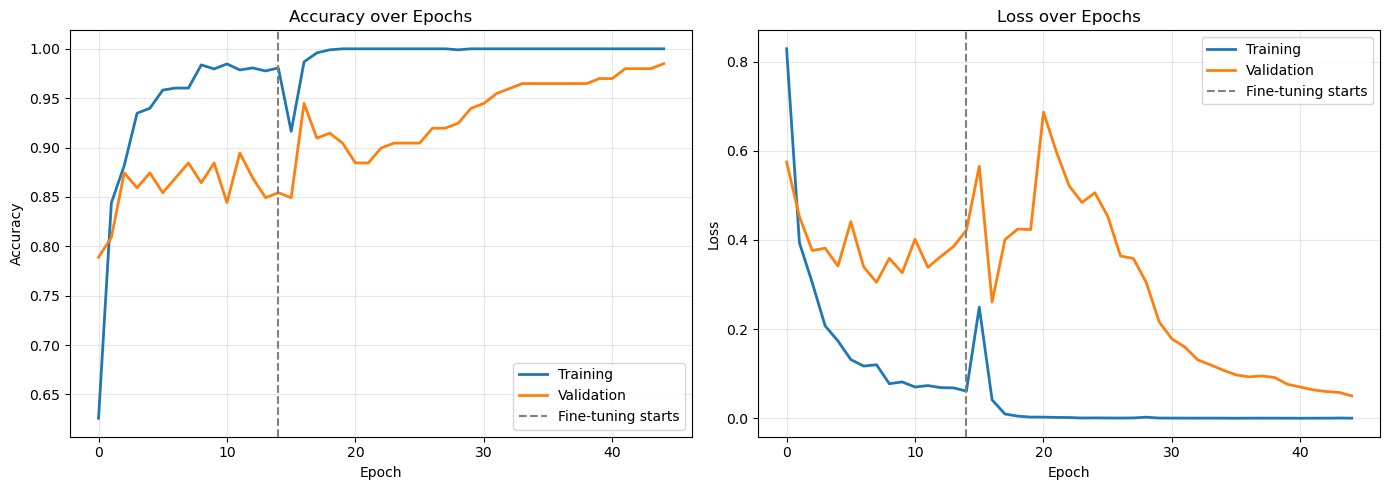

Best epoch:               45
Best validation accuracy: 0.9849
Train acc at best epoch:  1.0000
Train/val gap:            0.0151


In [11]:
# Combine histories from both phases
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(acc, label='Training', linewidth=2)
axes[0].plot(val_acc, label='Validation', linewidth=2)
axes[0].axvline(x=PHASE1_EPOCHS - 1, color='gray', linestyle='--', label='Fine-tuning starts')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(loss, label='Training', linewidth=2)
axes[1].plot(val_loss, label='Validation', linewidth=2)
axes[1].axvline(x=PHASE1_EPOCHS - 1, color='gray', linestyle='--', label='Fine-tuning starts')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = np.argmax(val_acc)
print(f'Best epoch:               {best_epoch + 1}')
print(f'Best validation accuracy: {max(val_acc):.4f}')
print(f'Train acc at best epoch:  {acc[best_epoch]:.4f}')
print(f'Train/val gap:            {acc[best_epoch] - val_acc[best_epoch]:.4f}')

---
## 8.&nbsp; Evaluate on Test Set

In [12]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f'Test Accuracy:  {test_acc:.4f}')
print(f'Test Loss:      {test_loss:.4f}')
print(f'Total Time:     {total_time/60:.1f} min')

Test Accuracy:  0.9749
Test Loss:      0.1065
Total Time:     11.3 min


In [13]:
y_true_list = []
y_pred_list = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_list.extend(np.argmax(preds, axis=1))
    y_true_list.extend(labels.numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

           A       1.00      0.98      0.99        43
           B       0.93      1.00      0.96        64
           C       1.00      0.96      0.98        92

    accuracy                           0.97       199
   macro avg       0.98      0.98      0.98       199
weighted avg       0.98      0.97      0.98       199



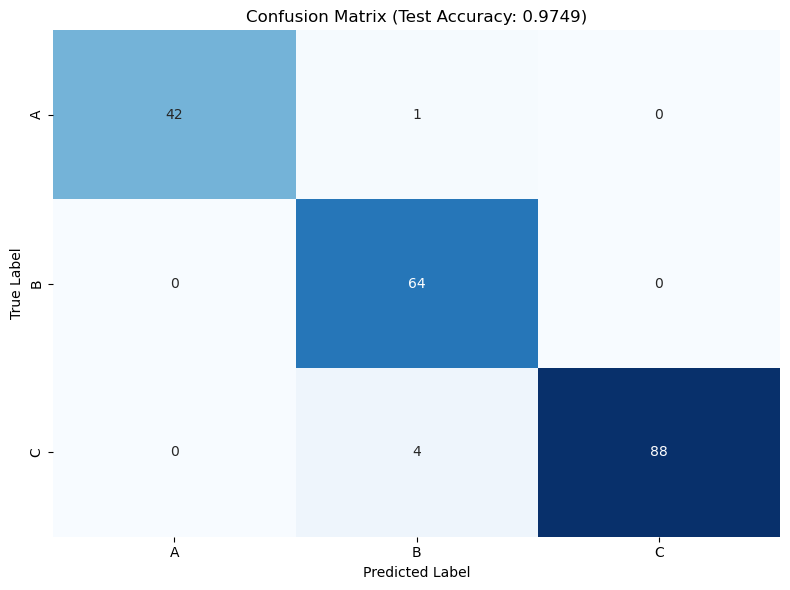

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Test Accuracy: {test_acc:.4f})')
plt.tight_layout()
plt.show()

---
## 9.&nbsp; Per-Class Accuracy

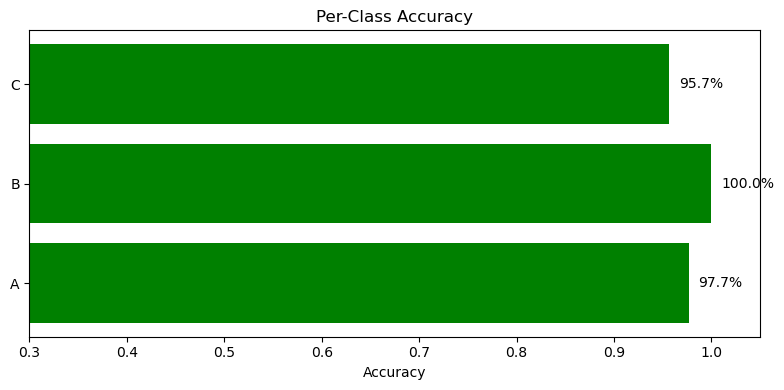

In [15]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(8, 4))
colours = ['green' if a > 0.90 else 'orange' if a > 0.75 else 'red' for a in per_class_acc]
plt.barh(class_names, per_class_acc, color=colours)
plt.xlabel('Accuracy')
plt.xlim(0.3, 1.05)
plt.title('Per-Class Accuracy')
for i, v in enumerate(per_class_acc):
    plt.text(v + 0.01, i, f'{v:.1%}', va='center')
plt.tight_layout()
plt.show()

---
## 10.&nbsp; Misclassified Images

Misclassified: 5 out of 199


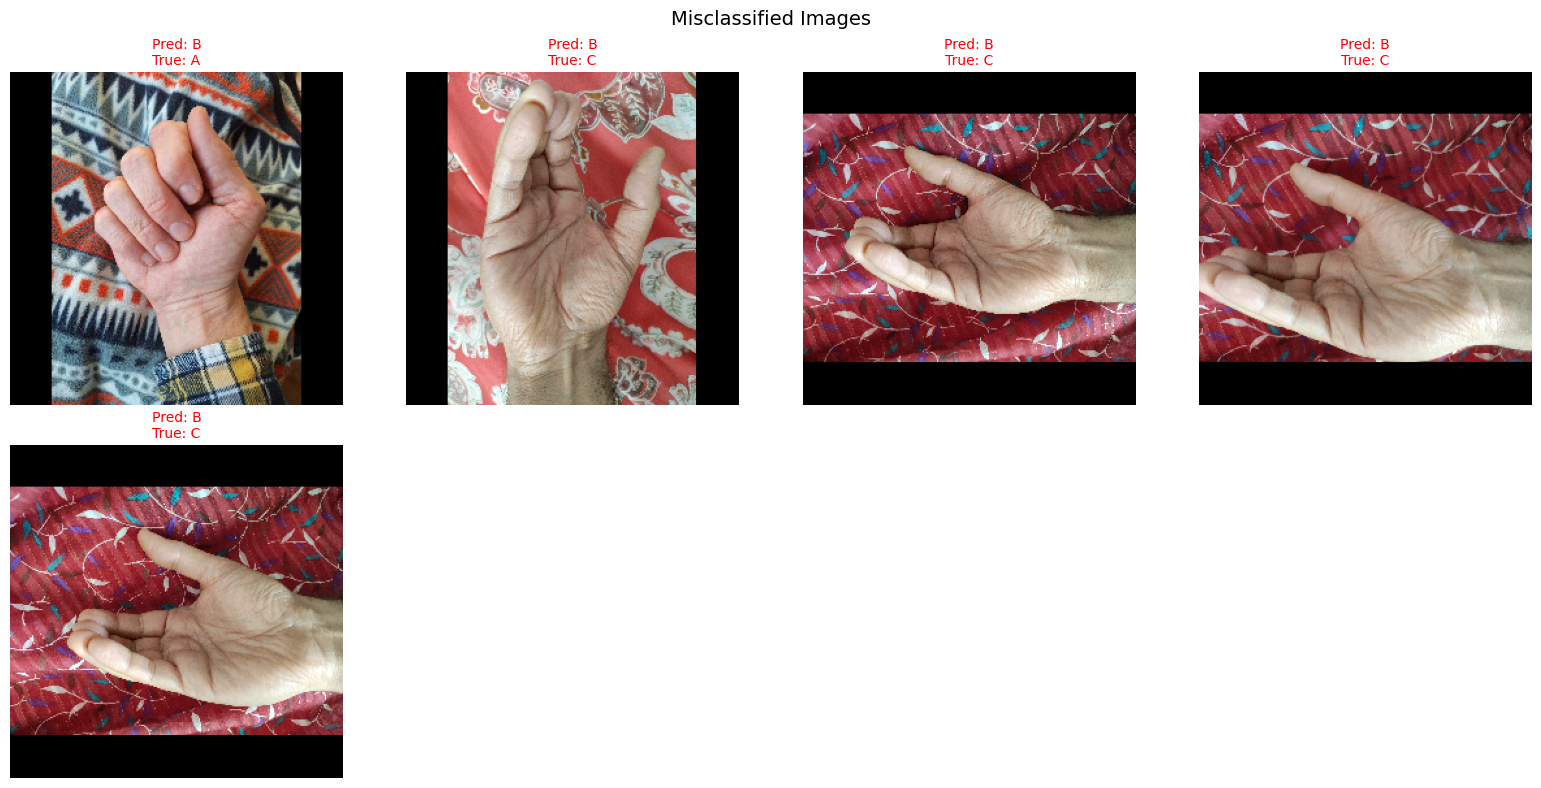

In [16]:
# Collect test images (need to re-load without MobileNet preprocessing for display)
all_test_images = []
for images, labels in datasets['test'].map(lambda img, lbl: (tf.cast(img, tf.float32) / 255.0, lbl)):
    all_test_images.extend(images.numpy())
all_test_images = np.array(all_test_images)

wrong_idx = np.where(y_pred != y_true)[0]
print(f'Misclassified: {len(wrong_idx)} out of {len(y_true)}')

if len(wrong_idx) > 0:
    n_show = min(12, len(wrong_idx))
    cols = min(4, n_show)
    rows = (n_show + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))
    for i in range(n_show):
        idx = wrong_idx[i]
        plt.subplot(rows, cols, i + 1)
        plt.imshow(all_test_images[idx])
        plt.title(
            f'Pred: {class_names[y_pred[idx]]}\nTrue: {class_names[y_true[idx]]}',
            color='red', fontsize=10
        )
        plt.axis('off')
    plt.suptitle('Misclassified Images', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No misclassifications!')

---
## 11.&nbsp; Reflect 📝

1. How much did transfer learning improve over training from scratch?
2. Did Phase 2 (fine-tuning) improve over Phase 1 (frozen base)?
3. Look at the training curves — is the dashed line (where fine-tuning starts) visible as a jump?
4. Is the model still overfitting, underfitting, or balanced?
5. Why does a model trained on cats, dogs, and cars help classify hand signs?

*Write your reflections here:*

- ...
- ...
- ...